In [12]:
from actionet import impute_features
%load_ext autoreload
%autoreload 2

import actionet
import scipy
import numpy as np
import scanpy as sc
import anndata
import pandas as pd

import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
adata = anndata.read_h5ad("../data/test_adata_post.h5ad")

In [3]:
markers = actionet.find_markers(adata, adata.obs['CellLabel'], features_use="Gene", top_genes=30, return_type='dataframe')

Computing feature specificity ... done


In [16]:
X_out = actionet.impute_features(adata, features=["Drd2", "Drd1", "Mog", "Aqp4", "Chat", "Vcan"], features_use="Gene", layer='logcounts', alpha=0.85)

In [14]:
X_out

,Drd2,Drd1,Mog,Aqp4,Chat
0,3.549436,0.724922,0.153611,0.065573,0.063815
1,2.888919,1.290049,0.145327,0.083033,0.042495
2,3.438883,1.082334,0.145295,0.125840,0.064004
3,0.243561,1.254483,0.245927,2.658764,0.004191
4,0.225657,1.120732,0.116552,0.027086,0.016983
...,...,...,...,...,...
6785,0.371371,1.459873,0.260270,0.117291,0.000002
6786,0.333165,2.714772,4.024121,0.162146,0.006652
6787,2.641409,0.865846,0.108839,0.430759,0.049746
6788,0.285773,1.474491,4.373149,0.202254,0.008242


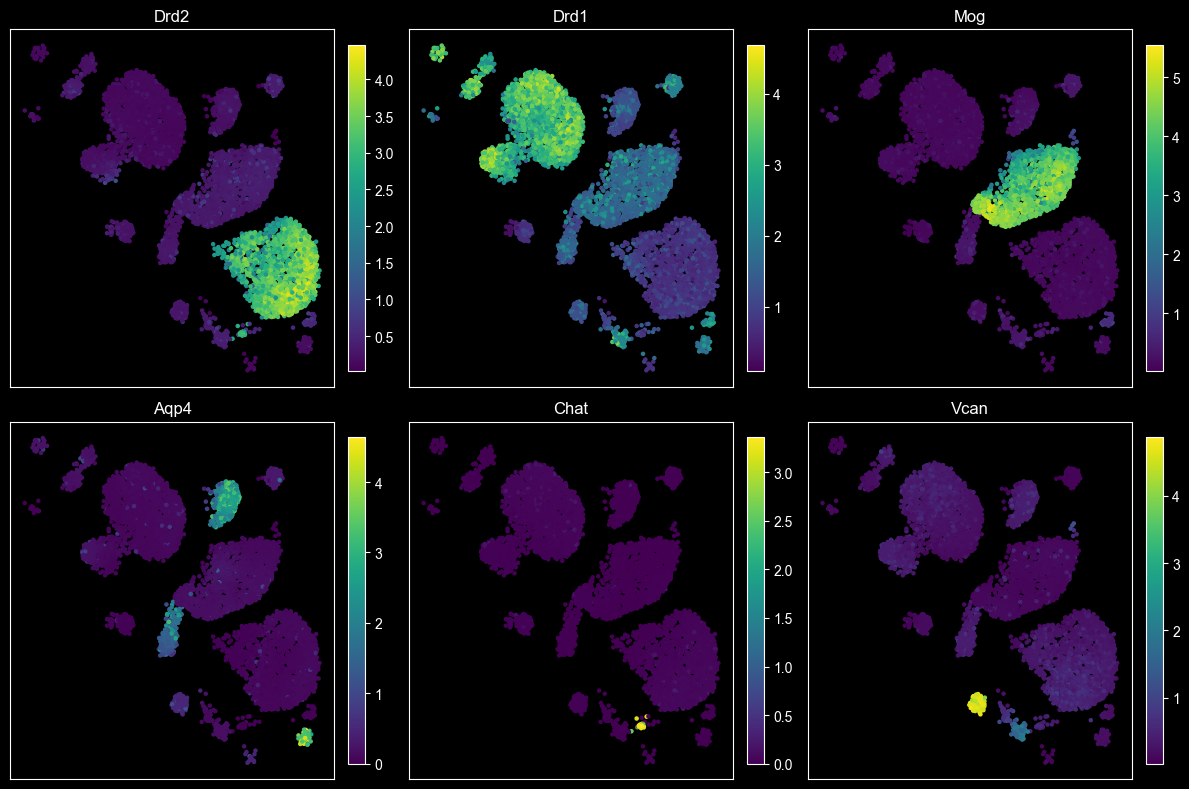

In [17]:
# Faceted UMAP colored by each imputed feature (columns of X_out)
features = X_out.columns.tolist()

n_features = X_out.shape[1]
cols = min(3, n_features)
rows = int(np.ceil(n_features / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), squeeze=False)

x = adata.obsm['umap'][:, 0]
y = adata.obsm['umap'][:, 1]

for i, ax in enumerate(axes.flat):
    if i >= n_features:
        ax.axis("off")
        continue

    sca = ax.scatter(
        x=x,
        y=y,
        c=X_out.iloc[:, i].to_numpy(),
        cmap='viridis',
        s=5
    )
    ax.set_title(features[i])
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(sca, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [18]:
adata.obs

,Barcode,CellLabel,assigned_archetype
0,CTGCGAGAGCTAGTTC-6,CT_15,8
1,TCAGTTTGTATGGAAT-6,CT_15,8
2,GGAAGTGCACATACGT-6,CT_15,8
3,CCCGAAGTCTTGCAAG-6,CT_1,3
4,AGTCAACCAAGGGTCA-6,CT_6,2
...,...,...,...
6785,CTTACCGAGTGCACAG-6,CT_13,23
6786,CGAGTTAGTGGAGGTT-6,CT_11,1
6787,CAGATCACAGCTATAC-6,CT_15,8
6788,CAACGGCAGTCACGCC-6,CT_11,1
